# Week 8 - Natural Language Processing
#### Part 4
### Notebook created by Jonathan Penava
By the end of this lesson you should be able to understand what Natural Language Processing is, and be able to train a NLP algorithm.

## Overview
- Understanding NLP
- Bag of Words and Word Vectors
- Regular Expressions
- <span style="color:red;">Naive Bayes</span>

We finally want to put our knowledge into a trained algorithm.  As practice we are going to read in a tab separated file which contains information about spam email messages.  

Resource : https://archive.ics.uci.edu/dataset/228/sms+spam+collection 


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Since we are not using a comma as a separator, we specify "sep" to indicate what our break is.

In [4]:
messages = pd.read_csv('SMSSpamCollection', sep='\t', names=["label", "message"])
messages.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
messages.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


We are going to add a new column to our data which contains the length of the message.  This might provide some interesting information that would help understand our classification.  We can also take some statistical data of our messages.

In [7]:
messages['length'] = messages['message'].apply(len)
messages.groupby('label').describe()

length                                                         
        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.482487  58.440652   2.0   33.0   52.0   93.0  910.0
spam    747.0  138.670683  28.873603  13.0  133.0  149.0  157.0  223.0

array([<Axes: title={'center': 'ham'}>, <Axes: title={'center': 'spam'}>],
      dtype=object)

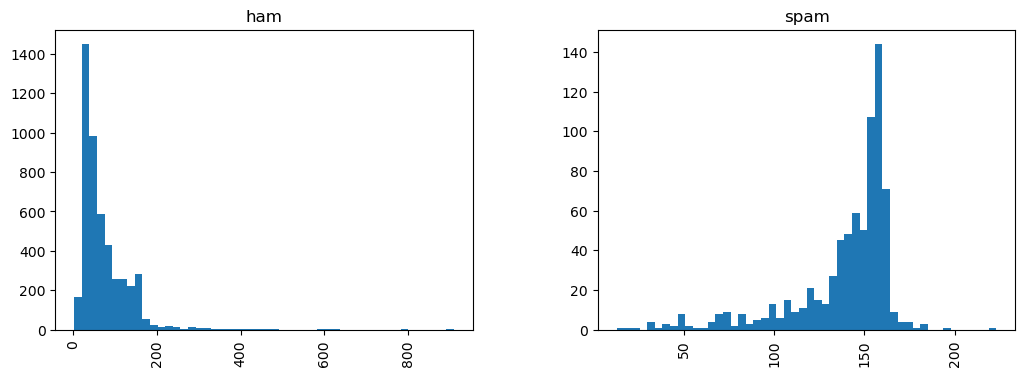

In [8]:
messages.hist(column='length', by='label', bins=50,figsize=(12,4))

Using the CountVectorizor we learned earlier we are going to transform our messages.

In [9]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
X = messages['message']
y = messages['label']
X = cv.fit_transform(X)


Performing our train test split and using Naïve Bayes to train our algorithm.

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=87)

In [11]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train,y_train)

MultinomialNB()

Checking our accuracy

In [12]:
predictions = nb.predict(X_test)
nb.score(X_test, y_test)

0.9796650717703349

In [13]:
from sklearn.metrics import confusion_matrix,classification_report
print(confusion_matrix(y_test,predictions))
print("[TP, FP] \n [FN, TN]")

[[1453   18]
 [  16  185]]
[TP, FP] 
 [FN, TN]


In [14]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99      1471
        spam       0.91      0.92      0.92       201

    accuracy                           0.98      1672
   macro avg       0.95      0.95      0.95      1672
weighted avg       0.98      0.98      0.98      1672



In [15]:
myTest = {
        'message':['Try your custom message here.']
       }
df = pd.DataFrame(myTest)
xt = df['message']
xt = cv.transform(xt)  #Use transform here instead of fit_transform
nb.predict(xt)


array(['ham'], dtype='<U4')